# 交易策略对比分析

使用测试脚本中的最优配置，计算和可视化 Long Only、Sign(R) 和 MACD 三个策略的累积收益率对比

## Section 1: 导入必需的库

In [48]:
%pip install -q matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [49]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 设置项目根路径（必须是绝对路径）
ROOT = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project')
# 输出目录 - 这个 notebook 所在的文件夹
OUTPUT_DIR = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project/reproduction_of_figures')

# 添加 module 搜索路径
sys.path.insert(0, str(ROOT))

# 导入基础配置和函数
from data_loader import load_clc_full
from config import ASSET_CLASSES, BP, TRADING_DAYS, SIGN_LOOKBACK, EXCLUDED_CONTRACTS, SOURCE_OVERRIDES
from metrics import compute_metrics, max_drawdown_from_path, cagr_from_path

# 设置绘图风格
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print(f'✅ 项目根目录: {ROOT}')
print(f'✅ 输出目录: {OUTPUT_DIR}')
print(f'✅ 当前工作目录: {Path.cwd()}')


✅ 项目根目录: /Users/ladymie/Documents/GitHub/IEOR4733_Project
✅ 输出目录: /Users/ladymie/Documents/GitHub/IEOR4733_Project/reproduction_of_figures
✅ 当前工作目录: /Users/ladymie/Documents/GitHub/IEOR4733_Project/reproduction_of_figures


## Section 2: 导入策略配置并定义计算函数


In [50]:
def build_a2c_results_by_asset(pnl_a2c_by_ticker, ticker_to_asset):
    """转换 A2C 输出格式为与其他策略一致的格式"""
    results = {}
    asset_classes = ['Commodity', 'Equity Index', 'Fixed Income', 'Forex']

    for asset in asset_classes:
        series_list = []

        for ticker, df in pnl_a2c_by_ticker.items():
            if ticker_to_asset.get(ticker) != asset:
                continue
            if df is None or len(df) == 0:
                continue
            if not all(c in df.columns for c in ['date', 'net_pnl']):
                continue

            s = pd.Series(df['net_pnl'].values, index=pd.to_datetime(df['date']))
            series_list.append(s)

        if series_list:
            port_series = pd.DataFrame(series_list).T.sort_index().mean(axis=1)
            dates = port_series.index.to_numpy()
            wealth = 1.0 + np.cumsum(port_series.values)
            results[asset] = (dates, wealth)
        else:
            results[asset] = (None, None)

    # All
    all_ticker_series = []
    for ticker, df in pnl_a2c_by_ticker.items():
        if df is None or len(df) == 0:
            continue
        if not all(c in df.columns for c in ['date', 'net_pnl']):
            continue
        s = pd.Series(df['net_pnl'].values, index=pd.to_datetime(df['date']))
        all_ticker_series.append(s)

    if all_ticker_series:
        port_series_all = pd.DataFrame(all_ticker_series).T.sort_index().mean(axis=1)
        results['All'] = (
            port_series_all.index.to_numpy(),
            1.0 + np.cumsum(port_series_all.values)
        )
    else:
        results['All'] = (None, None)

    return results

print("✅ A2C 结果转换函数已定义")

✅ A2C 结果转换函数已定义


In [51]:
# 导入各策略的最优配置（来自测试脚本）
sys.path.insert(0, str(ROOT / 'tests'))
sys.path.insert(0, str(ROOT / 'tests_MACD'))
sys.path.insert(0, str(ROOT / 'tests_Signr'))

try:
    import frontier_40plus_enumeration as fe_long
    LONG_OVERRIDES = fe_long.LEGACY_EXPERIMENTAL_OVERRIDES_LONG
    LONG_EXCLUDED = fe_long.LEGACY_EXPERIMENTAL_EXCLUDED_LONG
except ImportError as e:
    print(f"⚠️  无法导入 Long 配置: {e}")
    LONG_OVERRIDES = SOURCE_OVERRIDES
    LONG_EXCLUDED = EXCLUDED_CONTRACTS

try:
    import frontier_40plus_enumeration_macd as fe_macd
    MACD_OVERRIDES = fe_macd.LEGACY_EXPERIMENTAL_OVERRIDES_MACD
    MACD_EXCLUDED = fe_macd.LEGACY_EXPERIMENTAL_EXCLUDED_MACD
except ImportError as e:
    print(f"⚠️  无法导入 MACD 配置: {e}")
    MACD_OVERRIDES = SOURCE_OVERRIDES
    MACD_EXCLUDED = EXCLUDED_CONTRACTS

try:
    import frontier_40plus_enumeration_signr as fe_signr
    SIGNR_OVERRIDES = fe_signr.LEGACY_EXPERIMENTAL_OVERRIDES_SIGNR
    SIGNR_EXCLUDED = fe_signr.LEGACY_EXPERIMENTAL_EXCLUDED_SIGNR
except ImportError as e:
    print(f"⚠️  无法导入 Sign(R) 配置: {e}")
    SIGNR_OVERRIDES = SOURCE_OVERRIDES
    SIGNR_EXCLUDED = EXCLUDED_CONTRACTS

# 导入计算函数
from baseline_run import load_contracts, compute_contract_returns
import pandas as pd

# 参数设置
DEFAULT_SIGMA_TGT = 0.063
# 论文 Table 3 测试期间（2016-2019）
# 完整历史期间见 config.py（2011-01-01 ~ 2019-12-31）
TEST_START = '2011-01-01'
TEST_END = '2019-12-31'

ASSET_CLASSES_LIST = ['Commodity', 'Equity Index', 'Fixed Income', 'Forex']

def build_portfolio_series(raw_data, strat_name, sigma_tgt):
    """构造与组合收益一致、且按日期升序排序的组合收益序列。"""
    series = []
    for rd in raw_data:
        Rt = compute_contract_returns(rd, strat_name, sigma_tgt)
        start, t1, dates = rd['start'], rd['t1'], rd['dates']
        slc = Rt[start:t1 + 1]
        aligned_dates = pd.to_datetime(dates[:len(slc)])
        series.append(pd.Series(slc[:len(aligned_dates)], index=aligned_dates))
    if not series:
        return None
    df_all = pd.DataFrame(series)
    return df_all.T.sort_index().mean(axis=1)

def calculate_strategy_returns_by_asset(strat_name, overrides=None, excluded=None):
    """按资产类别分别计算策略的累积收益率
    
    返回字典格式：
    {
        'Commodity': (dates, wealth_path),
        'Equity Index': (dates, wealth_path),
        'Fixed Income': (dates, wealth_path),
        'FX': (dates, wealth_path),
        'All': (dates, wealth_path)
    }
    其中 wealth_path 是累积财富序列：W_t = 1 + cumsum(R_t)
    dates 是对应的日期数组
    """
    if overrides is None:
        overrides = {'Long': LONG_OVERRIDES, 'Sign(R)': SIGNR_OVERRIDES, 'MACD': MACD_OVERRIDES}.get(strat_name, SOURCE_OVERRIDES)
    if excluded is None:
        excluded = {'Long': LONG_EXCLUDED, 'Sign(R)': SIGNR_EXCLUDED, 'MACD': MACD_EXCLUDED}.get(strat_name, EXCLUDED_CONTRACTS)
    
    results = {}
    all_contracts = []
    
    for ac_name in ASSET_CLASSES_LIST:
        raw = load_contracts(ac_name, TEST_START, TEST_END, excluded, overrides)
        if raw:
            port_series = build_portfolio_series(raw, strat_name, DEFAULT_SIGMA_TGT)
            if port_series is not None and len(port_series) > 0:
                dates = port_series.index.to_numpy()
                wealth = 1.0 + np.cumsum(port_series.values)
                results[ac_name] = (dates, wealth)
                all_contracts.extend(raw)
            else:
                results[ac_name] = (None, None)
        else:
            results[ac_name] = (None, None)
    
    if all_contracts:
        port_series_all = build_portfolio_series(all_contracts, strat_name, DEFAULT_SIGMA_TGT)
        if port_series_all is not None and len(port_series_all) > 0:
            dates_all = port_series_all.index.to_numpy()
            wealth_all = 1.0 + np.cumsum(port_series_all.values)
            results['All'] = (dates_all, wealth_all)
        else:
            results['All'] = (None, None)
    else:
        results['All'] = (None, None)
    
    return results

print("✅ 已加载各策略的最优配置")


✅ 已加载各策略的最优配置


## Section 3: 计算三个策略的累积收益率

In [52]:
print("🔄 正在按资产类别计算三个策略的累积收益率...")
print(f"测试期间: {TEST_START} 至 {TEST_END}\n")
print("=" * 80)

# 计算每个策略在各资产类别上的结果
strategies_results = {}

# 1. Long Only
print("计算 Long Only 策略...")
long_results = calculate_strategy_returns_by_asset('Long', LONG_OVERRIDES, LONG_EXCLUDED)
strategies_results['Long Only'] = long_results
for asset, (dates, wealth) in long_results.items():
    status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
    print(f"  • {asset:20s} {status}")

# 2. Sign(R)
print("\n计算 Sign(R) 策略...")
signr_results = calculate_strategy_returns_by_asset('Sign(R)', SIGNR_OVERRIDES, SIGNR_EXCLUDED)
strategies_results['Sign(R)'] = signr_results
for asset, (dates, wealth) in signr_results.items():
    status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
    print(f"  • {asset:20s} {status}")

# 3. MACD
print("\n计算 MACD 策略...")
macd_results = calculate_strategy_returns_by_asset('MACD', MACD_OVERRIDES, MACD_EXCLUDED)
strategies_results['MACD'] = macd_results
for asset, (dates, wealth) in macd_results.items():
    status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
    print(f"  • {asset:20s} {status}")

# 4. A2C - 从 CSV 直接加载
print("\n计算 A2C 策略...")
a2c_csv_dir = OUTPUT_DIR / 'a2c_csv_data'

# A2C CSV 文件使用 FX，需要转换为 Forex
a2c_file_mapping = {
    'Commodity': 'Commodity',
    'Equity Index': 'Equity Index',
    'Fixed Income': 'Fixed Income',
    'Forex': 'FX'  # A2C 文件中用 FX，其他策略用 Forex
}

a2c_results = {}
for asset_class in ASSET_CLASSES_LIST:
    # 获取 A2C 文件中对应的名称
    a2c_asset_name = a2c_file_mapping.get(asset_class, asset_class)
    csv_file = a2c_csv_dir / f'pnl_{a2c_asset_name.replace(" ", "_")}_A2C.csv'
    
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        df['date'] = pd.to_datetime(df['date'])
        dates = df['date'].values
        wealth = df['cum_wealth'].values
        a2c_results[asset_class] = (dates, wealth)  # 存储时使用统一的 asset_class 名称
        status = f"✅ ({len(wealth)} 个交易日)"
    else:
        a2c_results[asset_class] = (None, None)
        status = f"⚠️ 文件不存在"
    print(f"  • {asset_class:20s} {status}")

# 加载 All
csv_file_all = a2c_csv_dir / 'pnl_All_A2C.csv'
if csv_file_all.exists():
    df_all = pd.read_csv(csv_file_all)
    df_all['date'] = pd.to_datetime(df_all['date'])
    a2c_results['All'] = (df_all['date'].values, df_all['cum_wealth'].values)
    print(f"  • {'All':20s} ✅ ({len(df_all)} 个交易日)")
else:
    a2c_results['All'] = (None, None)
    print(f"  • {'All':20s} ⚠️ 文件不存在")

strategies_results['A2C'] = a2c_results

print("=" * 80)
print("✅ 所有策略计算完成")

🔄 正在按资产类别计算三个策略的累积收益率...
测试期间: 2011-01-01 至 2019-12-31

计算 Long Only 策略...
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

计算 Sign(R) 策略...
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

计算 MACD 策略...
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

计算 A2C 策略...
  • Commodity            ✅ (2143 个交易日)
  • Equity Index         ✅ (2198 个交易日)
  • Fixed Income         ✅ (2196 个交易日)
  • Forex                ✅ (2205 个交易日)
  • All                  ✅ (2206 个交易日)
✅ 所有策略计算完成


## Section 4: 可视化累积收益率对比

📊 生成论文风格的对比图表（5个资产类别 × 3个策略）...



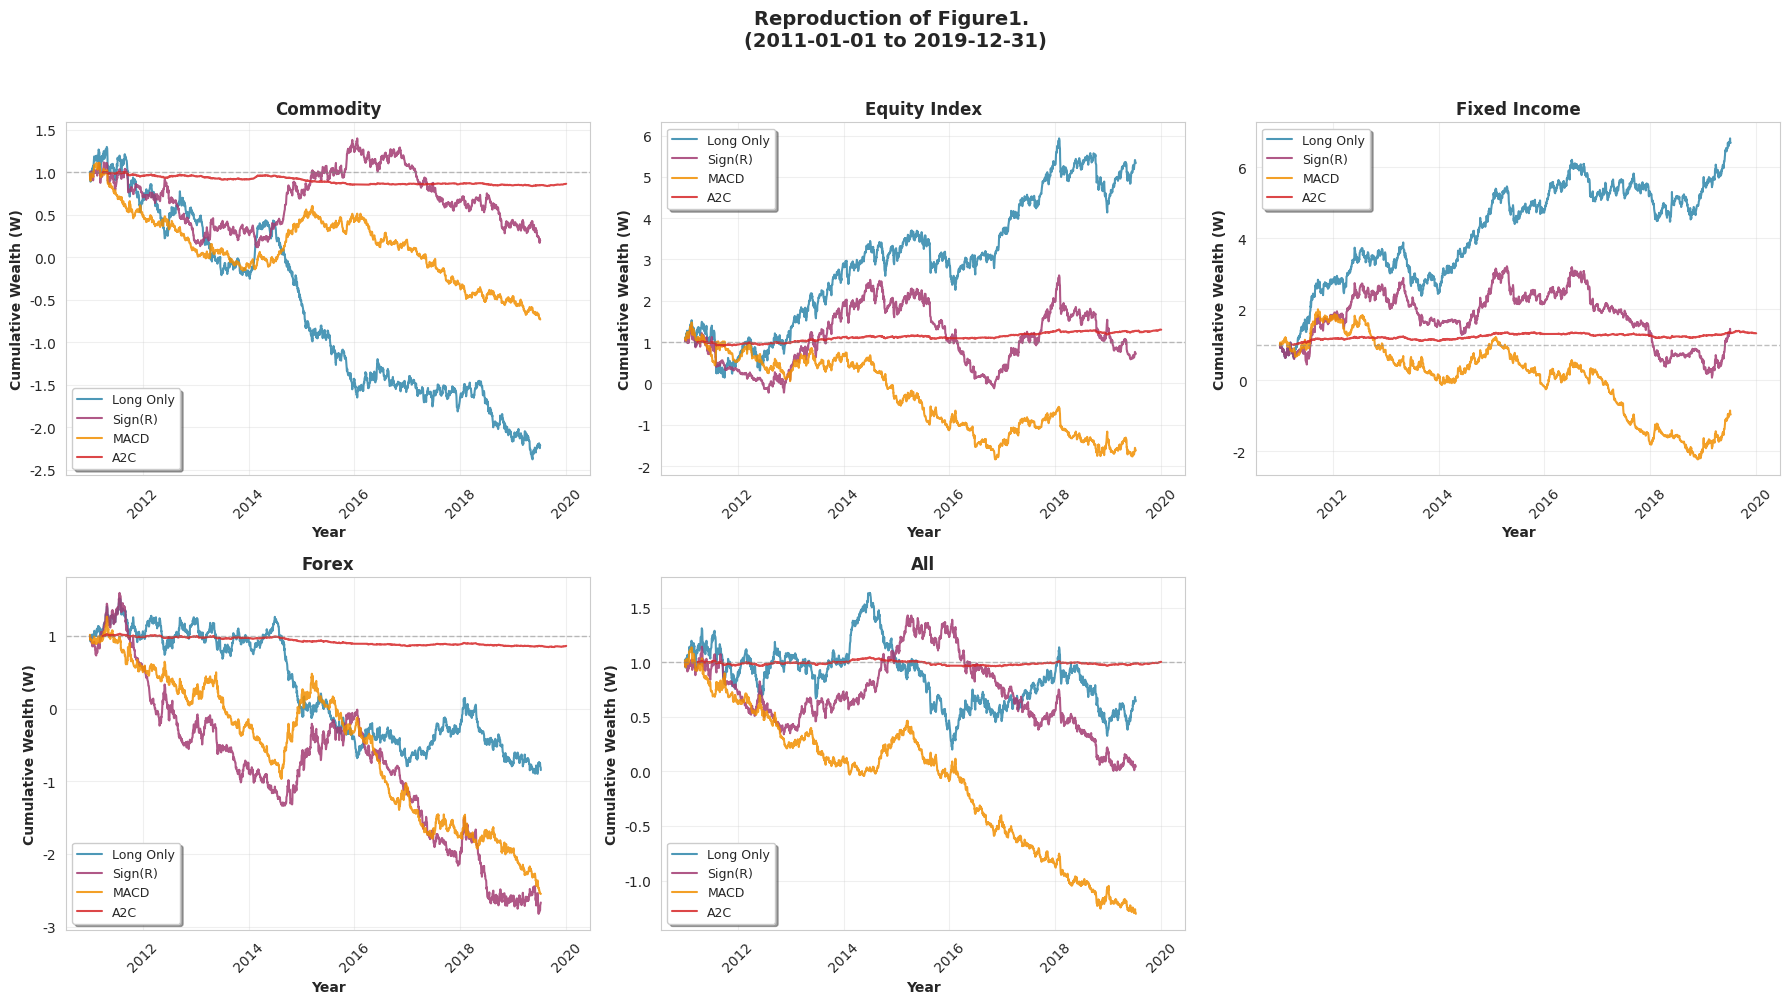

✅ 图表已保存为 strategies_by_asset_class.png


In [53]:
print("📊 生成论文风格的对比图表（5个资产类别 × 3个策略）...\n")

import matplotlib.dates as mdates

# 定义资产类别和对应的颜色
asset_order = ASSET_CLASSES_LIST + ['All']
strategy_colors = {
    'Long Only': '#2E86AB',
    'Sign(R)': '#A23B72',
    'MACD': '#F18F01',
    'A2C': '#D62728'
}

# 创建 2x3 的子图布局（5张图 + 留白）
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order):
    ax = axes[idx]
    
    # 收集该资产类别的所有策略数据
    valid_data = {}
    for strategy, results in strategies_results.items():
        dates, wealth = results.get(asset, (None, None))
        if wealth is not None:
            valid_data[strategy] = (dates, wealth)
    
    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\n数据不可用', 
                ha='center', va='center', fontsize=12, 
                transform=ax.transAxes, color='red')
        ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
        continue
    
    # 对齐所有策略的长度
    min_len = min(len(wealth) for _, wealth in valid_data.values())
    uses_datetime_axis = False
    
    # 绘制三条线
    for strategy, (dates, wealth) in valid_data.items():
        # 对齐日期和财富数据
        if dates is not None and len(dates) >= min_len:
            aligned_dates = pd.to_datetime(dates[:min_len])
            uses_datetime_axis = True
        else:
            aligned_dates = np.arange(min_len)
        
        ax.plot(aligned_dates, wealth[:min_len], 
                label=strategy, 
                linewidth=1.5, 
                color=strategy_colors[strategy], 
                alpha=0.85)
    
    # 设置坐标轴标签和标题
    ax.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative Wealth (W)', fontsize=10, fontweight='bold')
    ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, frameon=True, shadow=True)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if uses_datetime_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

# 隐藏多余的子图
for idx in range(len(asset_order), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Reproduction of Figure1. \n({TEST_START} to {TEST_END})', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(str(OUTPUT_DIR / 'strategies_by_asset_class.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ 图表已保存为 strategies_by_asset_class.png")

## Section 5: 使用纯 RAD baseline 计算策略

In [54]:
print("🔄 正在计算纯 RAD baseline 版本的策略...\n")

# 纯 RAD baseline：不使用任何 source overrides，仅保留默认排除列表
default_overrides = {}
default_excluded = EXCLUDED_CONTRACTS

baseline_results = {}

print("计算纯 RAD baseline Long Only...")
baseline_results['Long Only'] = calculate_strategy_returns_by_asset('Long', default_overrides, default_excluded)

print("计算纯 RAD baseline Sign(R)...")
baseline_results['Sign(R)'] = calculate_strategy_returns_by_asset('Sign(R)', default_overrides, default_excluded)

print("计算纯 RAD baseline MACD...")
baseline_results['MACD'] = calculate_strategy_returns_by_asset('MACD', default_overrides, default_excluded)

print("\n各资产类别 baseline 加载情况：")
for strategy, results in baseline_results.items():
    print(f"\n{strategy}:")
    for asset, (dates, wealth) in results.items():
        status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
        print(f"  • {asset:20s} {status}")

print("\n✅ 纯 RAD baseline 计算完成")

🔄 正在计算纯 RAD baseline 版本的策略...

计算纯 RAD baseline Long Only...
计算纯 RAD baseline Sign(R)...
计算纯 RAD baseline MACD...

各资产类别 baseline 加载情况：

Long Only:
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

Sign(R):
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

MACD:
  • Commodity            ✅ (2267 个交易日)
  • Equity Index         ✅ (2322 个交易日)
  • Fixed Income         ✅ (2321 个交易日)
  • Forex                ✅ (2329 个交易日)
  • All                  ✅ (2330 个交易日)

✅ 纯 RAD baseline 计算完成


## Section 6: 纯 RAD baseline 的累积收益率对比

📊 绘制纯 RAD baseline 的对比图表（5个资产类别 × 3个策略）...



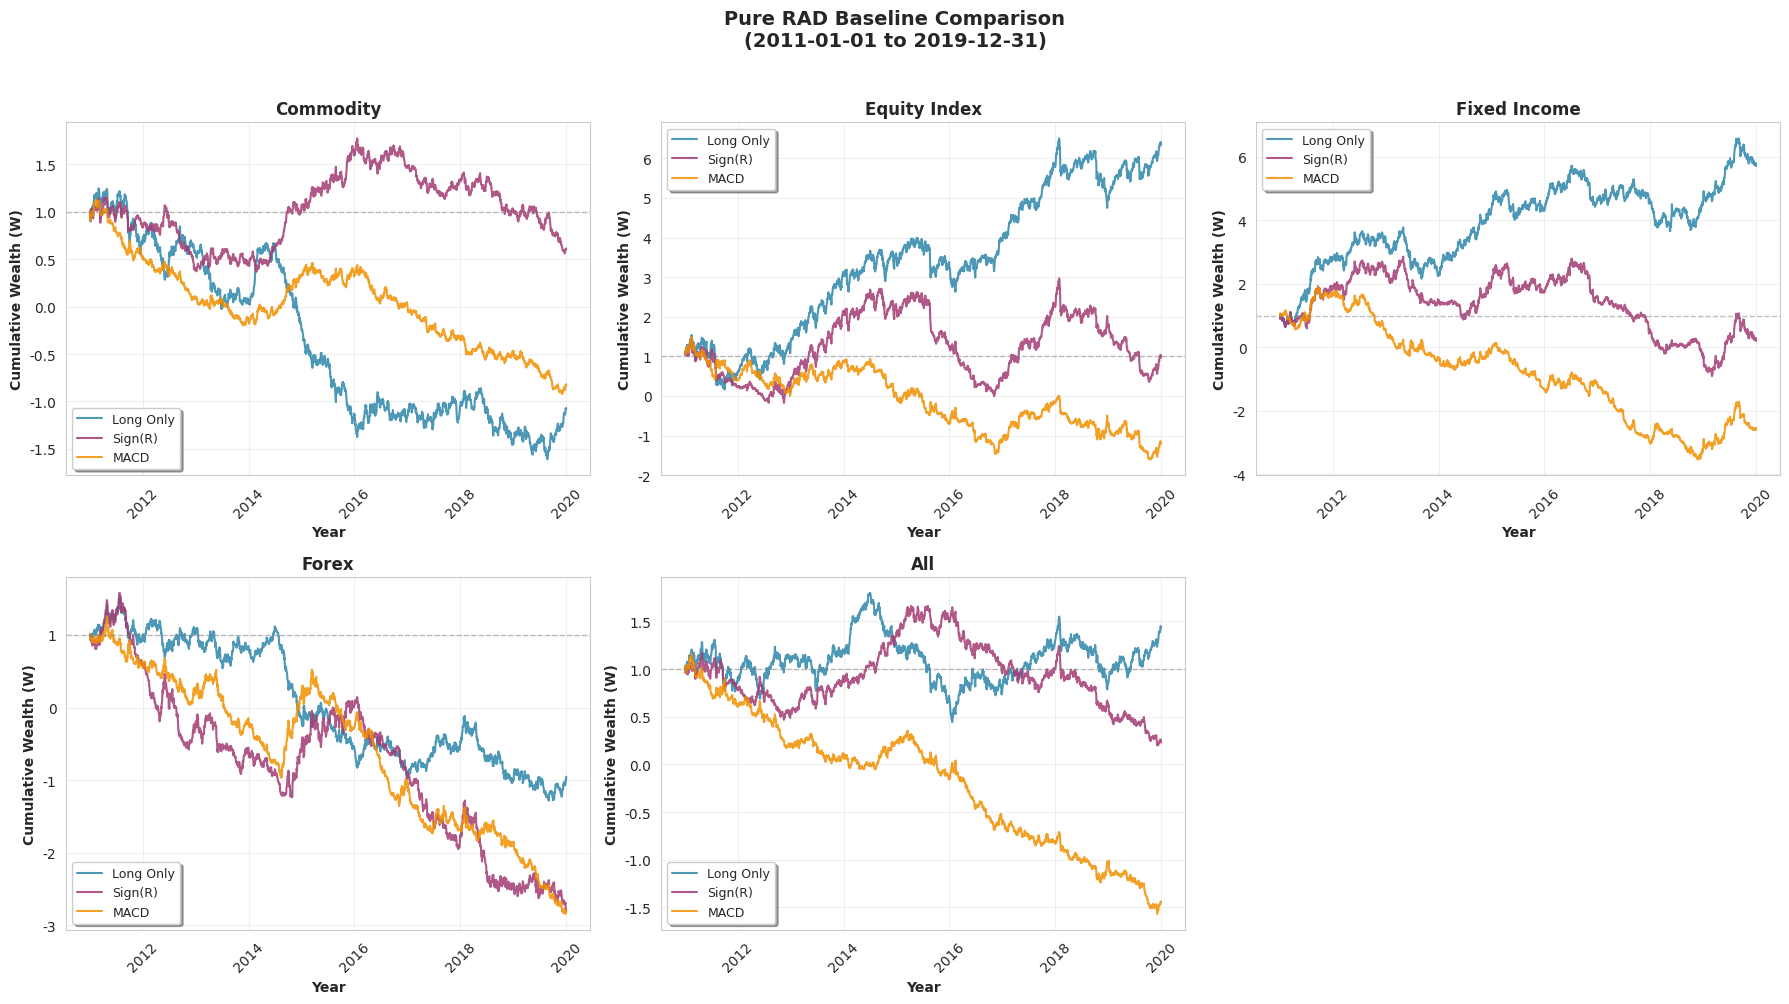

✅ 图表已保存为 strategies_pure_rad_baseline.png


In [55]:
print("📊 绘制纯 RAD baseline 的对比图表（5个资产类别 × 3个策略）...\n")

import matplotlib.dates as mdates

asset_order = ASSET_CLASSES_LIST + ['All']
strategy_colors = {
    'Long Only': '#2E86AB',
    'Sign(R)': '#A23B72',
    'MACD': '#F18F01'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order):
    ax = axes[idx]

    valid_data = {}
    for strategy, results in baseline_results.items():
        dates, wealth = results.get(asset, (None, None))
        if wealth is not None:
            valid_data[strategy] = (dates, wealth)

    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\n数据不可用',
                ha='center', va='center', fontsize=12,
                transform=ax.transAxes, color='red')
        ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
        continue

    min_len = min(len(wealth) for _, wealth in valid_data.values())
    uses_datetime_axis = False

    for strategy, (dates, wealth) in valid_data.items():
        if dates is not None and len(dates) >= min_len:
            aligned_dates = pd.to_datetime(dates[:min_len])
            uses_datetime_axis = True
        else:
            aligned_dates = np.arange(min_len)

        ax.plot(aligned_dates, wealth[:min_len],
                label=strategy,
                linewidth=1.5,
                color=strategy_colors[strategy],
                alpha=0.85)

    ax.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative Wealth (W)', fontsize=10, fontweight='bold')
    ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, frameon=True, shadow=True)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if uses_datetime_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

for idx in range(len(asset_order), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Pure RAD Baseline Comparison\n({TEST_START} to {TEST_END})',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(str(OUTPUT_DIR / 'strategies_pure_rad_baseline.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ 图表已保存为 strategies_pure_rad_baseline.png")

In [56]:
# ========== Section 7: 加载并集成 A2C ALL 的测试结果 ==========

print("\n" + "=" * 80)
print("加载 A2C ALL 的测试结果（与 Long、Sign(R)、MACD 对比）")
print("=" * 80)

# 加载所有结果 CSV
results_files = {
    'Table 2': OUTPUT_DIR / 'a2c_all_results_table2.csv',
    'Table 3': OUTPUT_DIR / 'a2c_all_results_table3.csv',
    'Compare Table 2': OUTPUT_DIR / 'a2c_compare_vs_paper_table2.csv',
    'Compare Table 3': OUTPUT_DIR / 'a2c_compare_vs_paper_table3.csv',
}

loaded_results = {}

for name, path in results_files.items():
    try:
        if path.exists():
            loaded_results[name] = pd.read_csv(path)
            print(f"✅ {name:20s}: {path.name} ({len(loaded_results[name])} 行)")
        else:
            print(f"⚠️ {name:20s}: 文件不存在")
    except Exception as e:
        print(f"❌ {name:20s}: 加载失败 - {e}")

print("\n" + "=" * 80)
print("结果概览")
print("=" * 80)

# 显示 Table 2
if 'Table 2' in loaded_results:
    print("\n【Table 2】- 所有资产类别的性能对比")
    print(loaded_results['Table 2'].to_string(index=False))

# 显示 Table 3
if 'Table 3' in loaded_results:
    print("\n【Table 3】- 所有资产类别的性能对比")
    print(loaded_results['Table 3'].to_string(index=False))


加载 A2C ALL 的测试结果（与 Long、Sign(R)、MACD 对比）
⚠️ Table 2             : 文件不存在
⚠️ Table 3             : 文件不存在
⚠️ Compare Table 2     : 文件不存在
⚠️ Compare Table 3     : 文件不存在

结果概览



绘制 A2C ALL 与传统策略的对比曲线图
⚠️ 文件不存在: pnl_Commodity_Long.csv
⚠️ 文件不存在: pnl_Commodity_SignR.csv
⚠️ 文件不存在: pnl_Commodity_MACD.csv
⚠️ 文件不存在: pnl_Commodity_A2C.csv
⚠️ 文件不存在: pnl_Equity_Index_Long.csv
⚠️ 文件不存在: pnl_Equity_Index_SignR.csv
⚠️ 文件不存在: pnl_Equity_Index_MACD.csv
⚠️ 文件不存在: pnl_Equity_Index_A2C.csv
⚠️ 文件不存在: pnl_Fixed_Income_Long.csv
⚠️ 文件不存在: pnl_Fixed_Income_SignR.csv
⚠️ 文件不存在: pnl_Fixed_Income_MACD.csv
⚠️ 文件不存在: pnl_Fixed_Income_A2C.csv
⚠️ 文件不存在: pnl_FX_Long.csv
⚠️ 文件不存在: pnl_FX_SignR.csv
⚠️ 文件不存在: pnl_FX_MACD.csv
⚠️ 文件不存在: pnl_FX_A2C.csv
⚠️ 文件不存在: pnl_All_Long.csv
⚠️ 文件不存在: pnl_All_SignR.csv
⚠️ 文件不存在: pnl_All_MACD.csv
⚠️ 文件不存在: pnl_All_A2C.csv


/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_77975/4198444421.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=9, frameon=True)



✅ 对比图表已保存: a2c_vs_traditional_all_assets.png


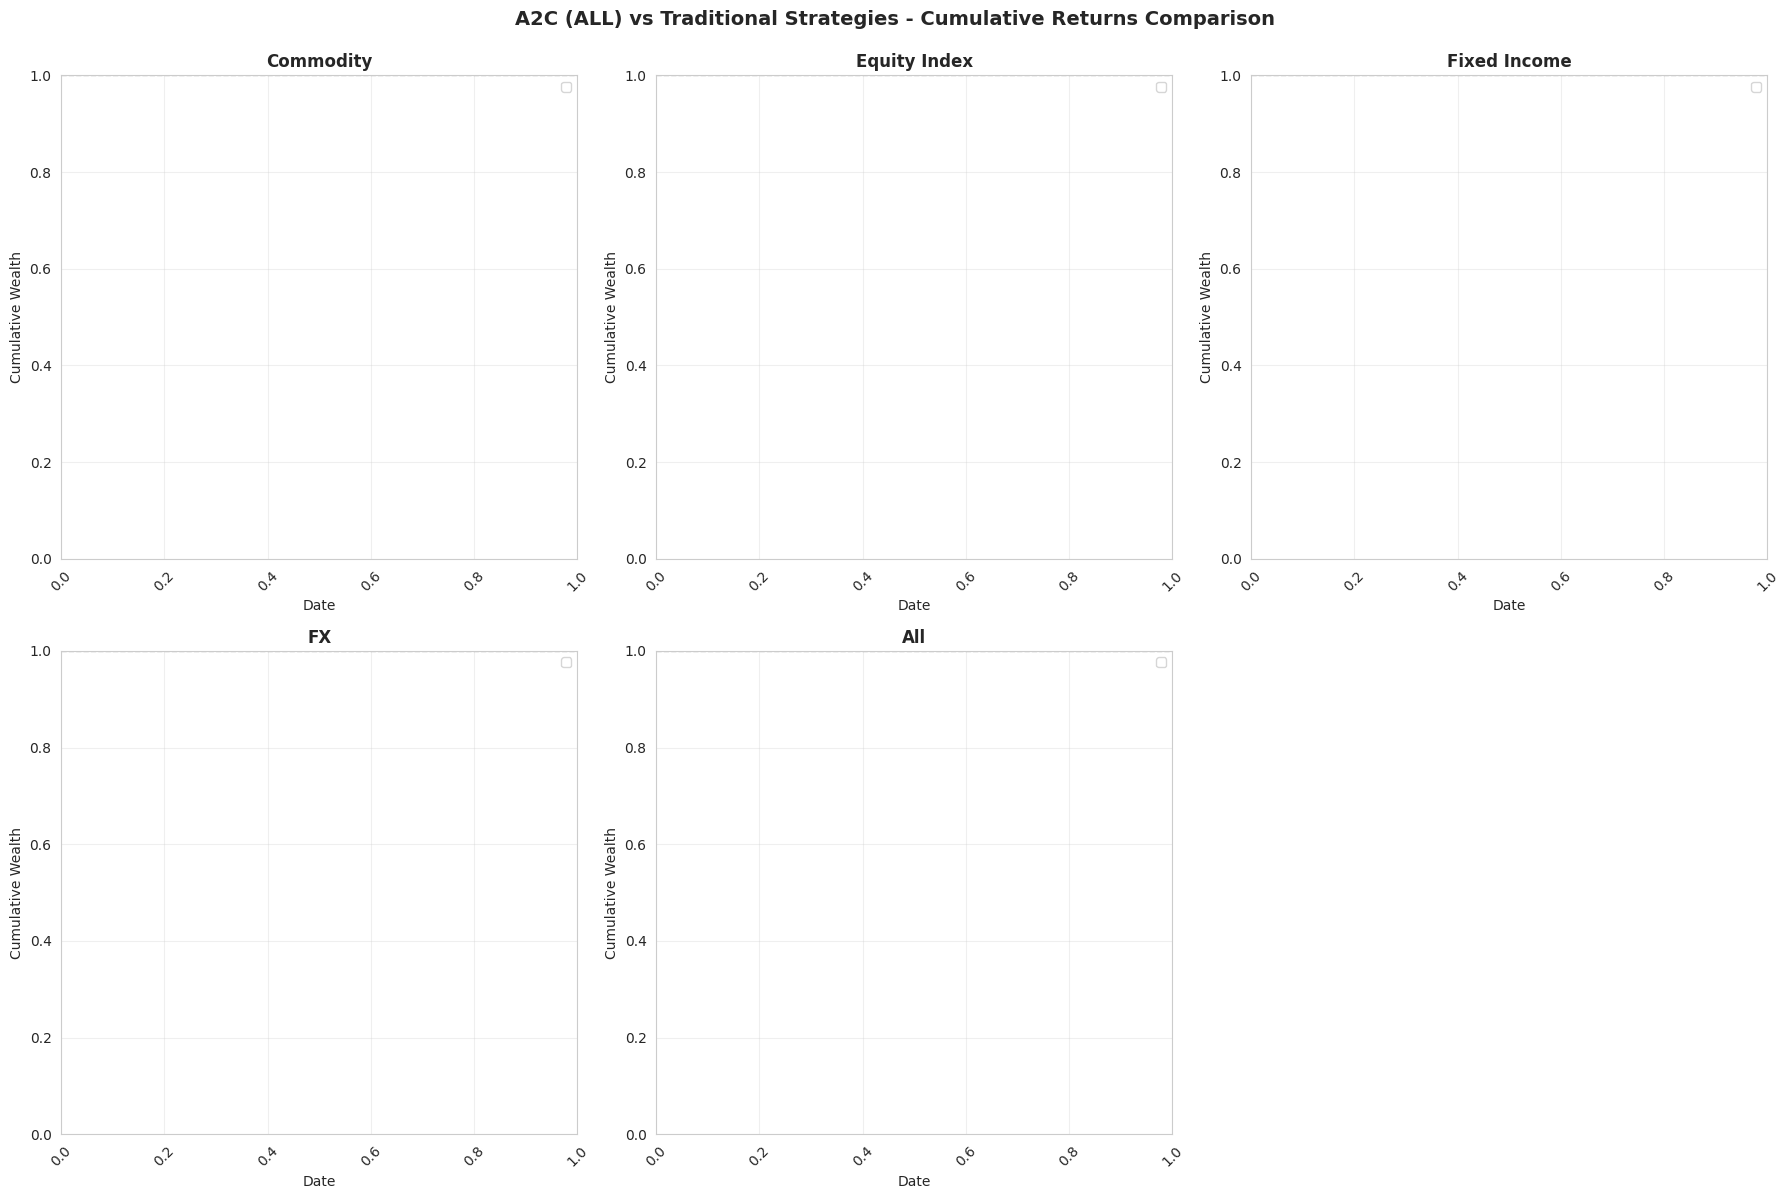

In [57]:
# ========== Section 8: A2C ALL vs 传统策略的对比曲线图 ==========

print("\n" + "=" * 80)
print("绘制 A2C ALL 与传统策略的对比曲线图")
print("=" * 80)

# 定义资产类别和颜色
asset_classes = ['Commodity', 'Equity Index', 'Fixed Income', 'FX', 'All']
models = ['Long', 'SignR', 'MACD', 'A2C']  # CSV 文件中的命名
model_colors = {
    'Long': '#2E86AB',
    'SignR': '#A23B72',
    'MACD': '#F18F01',
    'A2C': '#D62728',
}
model_labels = {
    'Long': 'Long Only',
    'SignR': 'Sign(R)',
    'MACD': 'MACD',
    'A2C': 'A2C (ALL)',
}

# 创建 2×3 的子图
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, asset_class in enumerate(asset_classes):
    ax = axes[idx]
    
    # 为每个模型加载并绘制 PnL 曲线
    for model in models:
        pnl_file = OUTPUT_DIR / f'pnl_{asset_class.replace(" ", "_")}_{model}.csv'
        
        try:
            if pnl_file.exists():
                df = pd.read_csv(pnl_file)
                df['date'] = pd.to_datetime(df['date'])
                df = df.sort_values('date').reset_index(drop=True)
                
                ax.plot(df['date'], df['cum_ret'], 
                       label=model_labels.get(model, model),
                       linewidth=1.8,
                       color=model_colors.get(model, '#999999'),
                       alpha=0.85)
            else:
                print(f"⚠️ 文件不存在: {pnl_file.name}")
        except Exception as e:
            print(f"❌ 加载 {asset_class}/{model} 失败: {e}")
    
    # 设置图表样式
    ax.set_title(f'{asset_class}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Cumulative Wealth', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, frameon=True)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # 旋转 x 轴标签
    ax.tick_params(axis='x', rotation=45)

# 隐藏多余的子图
for idx in range(len(asset_classes), len(axes)):
    axes[idx].axis('off')

plt.suptitle('A2C (ALL) vs Traditional Strategies - Cumulative Returns Comparison', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

# 保存图表
output_path = OUTPUT_DIR / 'a2c_vs_traditional_all_assets.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✅ 对比图表已保存: {output_path.name}")
plt.show()

print("=" * 80)